In [1]:
import sys
from pathlib import Path
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import copy
import matplotlib.pyplot as plt

def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "data").exists():
            return p
    return start


PROJECT_ROOT = find_project_root()
sys.path.append(str(PROJECT_ROOT))



In [2]:
from src.io.pitch_io import load_preprocessed_pitch, load_pitch_file
from src.io.annotation_io import load_annotations
import settings as S

START_COL = "start_time_sec"
END_COL = "end_time_sec"



This block defines the parameters that control how pitch contours are converted into training data.

Key parameters:

- `WINDOW_SIZE`: number of samples per training window
- `STRIDE`: distance between consecutive windows
- `MIN_RUN_LEN`: minimum number of valid samples required for a contour fragment
- `NORMALIZE_PER_WINDOW`: whether each window is z-score normalized

These parameters determine how much local context the model sees and how many training examples are generated.

In [65]:
SEED = 42

WINDOW_SIZE = 32
MIN_RUN_LEN = WINDOW_SIZE

STRIDE = 8

NORMALIZE_PER_WINDOW = True

# data split
VAL_RATIO = 0.20

# masking
MIN_MASK_LEN = 4
MAX_MASK_LEN = 6
MASK_FILL_VALUE = 0.0
USE_MASK_CHANNEL = True

# dataloader
BATCH_SIZE = 64

# model
HIDDEN_CHANNELS = 32
DROPOUT = 0.05
IN_CHANNELS = 2 if USE_MASK_CHANNEL else 1

# training
NUM_EPOCHS = 150
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5


In [66]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Each training window can optionally be normalized using z-score normalization.

This transforms the window so that:

- mean = 0
- standard deviation = 1

Normalization helps the model focus on the **shape of the pitch trajectory** rather than absolute pitch height.

Since the pitch is already expressed in cents relative to the tonic, normalization mainly removes local offset differences.

In [67]:
def zscore_normalize(x, eps=1e-8):
    mean = x.mean()
    std = x.std()

    if std < eps:
        return x - mean

    return (x - mean) / (std + eps)

Long pitch contours are split into fixed-length windows.

Given a contour:

- windows of length `WINDOW_SIZE` are extracted
- consecutive windows are separated by `STRIDE` samples

This produces overlapping windows and increases the number of training examples.

For example, a contour of 1000 samples can produce dozens of training windows.

In [68]:
def slice_windows(contour, window_size=256, stride=64):
    windows = []
    n = len(contour)

    if n < window_size:
        return windows

    for start in range(0, n - window_size + 1, stride):
        end = start + window_size
        windows.append(contour[start:end])

    return windows


def build_window_corpus(clean_contours,
                        window_size=32,
                        stride=8,
                        normalize_per_window=True):
    all_windows = []

    for contour in clean_contours:
        windows = slice_windows(contour, window_size=window_size, stride=stride)

        for w in windows:
            w = np.asarray(w, dtype=np.float32)

            if normalize_per_window:
                w = zscore_normalize(w)

            all_windows.append(w.astype(np.float32))

    if len(all_windows) == 0:
        raise ValueError("No windows were created. Check MIN_RUN_LEN and WINDOW_SIZE.")

    return np.stack(all_windows, axis=0)

A boolean mask is constructed to identify pitch samples that are considered reliable.

This mask uses information already computed during preprocessing, such as:

- `too_long_to_interp`
- `is_outlier`
- `valid_for_pchip`

Only samples that pass these checks are considered valid.

Using these existing flags avoids repeating preprocessing steps and ensures consistency with the pitch cleaning pipeline.

In [69]:
def build_valid_sample_mask(df_pitch, df_pitch_aux, pitch_col):
    pitch_vals = df_pitch[pitch_col].to_numpy()
    valid_mask = np.isfinite(pitch_vals)

    if "too_long_to_interp" in df_pitch_aux.columns:
        valid_mask &= ~df_pitch_aux["too_long_to_interp"].to_numpy()

    if "is_outlier" in df_pitch_aux.columns:
        valid_mask &= ~df_pitch_aux["is_outlier"].to_numpy()

    if "valid_for_pchip" in df_pitch_aux.columns:
        valid_mask &= df_pitch_aux["valid_for_pchip"].to_numpy()

    return valid_mask

Within each segment, the code identifies contiguous sequences of valid samples.

Instead of removing invalid samples and compressing the contour, the algorithm detects **runs of consecutive valid points**.

Each run represents a temporally continuous portion of the pitch trajectory.

This prevents two valid fragments separated by invalid samples from being artificially merged into a single contour.

In [70]:

def find_true_runs(mask):
    """
    Returns a list of (start_idx, end_idx) pairs for contiguous True runs.
    end_idx is exclusive.
    """
    runs = []
    n = len(mask)

    i = 0
    while i < n:
        if mask[i]:
            start = i
            while i < n and mask[i]:
                i += 1
            end = i
            runs.append((start, end))
        else:
            i += 1

    return runs


Pitch contours are extracted for each annotated svara segment.

For every annotation:

1. The corresponding time interval is selected from the pitch dataframe.
2. The validity mask is applied.
3. Continuous valid runs are detected.
4. Runs shorter than `MIN_RUN_LEN` are discarded.

Each remaining run is stored as an independent pitch contour.

This produces a collection of clean pitch fragments that can be used for training.

In [71]:
def extract_segment_contours(df_pitch,
                             df_pitch_aux,
                             df_svaras,
                             pitch_col,
                             min_run_len=32):
    time_vals = df_pitch[S.TIME_COL].to_numpy()
    pitch_vals = df_pitch[pitch_col].to_numpy()

    valid_mask_global = build_valid_sample_mask(df_pitch, df_pitch_aux, pitch_col)

    starts = df_svaras[START_COL].to_numpy()
    ends = df_svaras[END_COL].to_numpy()

    clean_contours = []

    for start_sec, end_sec in zip(starts, ends):
        seg_mask = (time_vals >= start_sec) & (time_vals <= end_sec)

        seg_pitch = pitch_vals[seg_mask]
        seg_valid = valid_mask_global[seg_mask]

        runs = find_true_runs(seg_valid)

        for start_idx, end_idx in runs:
            contour = seg_pitch[start_idx:end_idx]

            if len(contour) < min_run_len:
                continue

            contour = np.asarray(contour, dtype=np.float32)

            if not np.all(np.isfinite(contour)):
                continue

            clean_contours.append(contour)

    if len(clean_contours) == 0:
        raise ValueError("No valid continuous contours were extracted.")

    return clean_contours

Two datasets are used:

- the **preprocessed pitch trajectory** of the recording
- the **svara annotation file**

The pitch is loaded with the option `convert_to_cents=True`, which converts frequencies from Hz to cents relative to the tonic.

Working in cents makes pitch trajectories comparable across recordings with different tonic frequencies.

In [ ]:
'''_seed(SEED)

recording_id = S.CURRENT_PIECE
tonic_hz = S.SARASUDA_TONICS[recording_id]
aux_pitch_path = S.DATA_INTERIM / recording_id / "pitch" / f"{recording_id}_pitch_preprocessed_debug.parquet"

annotation_path = (
    S.DATA_CORPUS
    / recording_id
    / "raw"
    / f"{recording_id}_ann_svara.tsv"
)

df_pitch = load_preprocessed_pitch(
    recording_id=recording_id,
    root_dir=S.DATA_INTERIM,
    tonic_hz=tonic_hz,
    convert_to_cents=True,
)

df_pitch_aux = load_pitch_file(
    file_path=aux_pitch_path
)

df_svaras = load_annotations(
    file_path=annotation_path,
    annotation_type="svara",
    engine="polars",
    
)

clean_contours = extract_segment_contours(
    df_pitch,
    df_pitch_aux,
    df_svaras=df_svaras,
    pitch_col=S.PITCH_COL_CENTS,
    min_run_len=MIN_RUN_LEN,
)

print("Number of clean continuous contours:", len(clean_contours))
print("First contour length:", len(clean_contours[0]))

windows = build_window_corpus(
    clean_contours=clean_contours,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    normalize_per_window=NORMALIZE_PER_WINDOW,
)

print("Window corpus shape:", windows.shape)
print("Example window shape:", windows[0].shape)
'''

'_seed(SEED)\n\nrecording_id = S.CURRENT_PIECE\ntonic_hz = S.SARASUDA_TONICS[recording_id]\naux_pitch_path = S.DATA_INTERIM / recording_id / "pitch" / f"{recording_id}_pitch_preprocessed_debug.parquet"\n\nannotation_path = (\n    S.DATA_CORPUS\n    / recording_id\n    / "raw"\n    / f"{recording_id}_ann_svara.tsv"\n)\n\ndf_pitch = load_preprocessed_pitch(\n    recording_id=recording_id,\n    root_dir=S.DATA_INTERIM,\n    tonic_hz=tonic_hz,\n    convert_to_cents=True,\n)\n\ndf_pitch_aux = load_pitch_file(\n    file_path=aux_pitch_path\n)\n\ndf_svaras = load_annotations(\n    file_path=annotation_path,\n    annotation_type="svara",\n    engine="polars",\n    \n)\n'

Using the previously defined functions, continuous pitch contours are extracted from the annotated segments.

Each contour corresponds to a continuous region of valid pitch samples within a svara segment.

The result is a list of 1D NumPy arrays, where each array represents a clean pitch trajectory fragment.

The extracted contours are finally converted into the training corpus.

Each contour is split into overlapping windows using the parameters:

- `WINDOW_SIZE`
- `STRIDE`

The result is a matrix of shape: [N_windows, WINDOW_SIZE] where each row corresponds to one training example.

In [75]:
#mixing all pieces together
'''
set_seed(SEED)

all_clean_contours = []

for recording_id in S.SARASUDA_VARNAM:

    print(f"\nProcessing piece: {recording_id}")

    tonic_hz = S.SARASUDA_TONICS[recording_id]

    aux_pitch_path = (
        S.DATA_INTERIM
        / recording_id
        / "pitch"
        / f"{recording_id}_pitch_preprocessed_debug.parquet"
    )

    annotation_path = (
        S.DATA_CORPUS
        / recording_id
        / "raw"
        / f"{recording_id}_ann_svara.tsv"
    )

    df_pitch = load_preprocessed_pitch(
        recording_id=recording_id,
        root_dir=S.DATA_INTERIM,
        tonic_hz=tonic_hz,
        convert_to_cents=True,
    )

    df_pitch_aux = load_pitch_file(
        file_path=aux_pitch_path
    )

    df_svaras = load_annotations(
        file_path=annotation_path,
        annotation_type="svara",
        engine="polars",
    )

    clean_contours = extract_segment_contours(
        df_pitch,
        df_pitch_aux,
        df_svaras=df_svaras,
        pitch_col=S.PITCH_COL_CENTS,
        min_run_len=MIN_RUN_LEN,
    )

    print("  contours:", len(clean_contours))

    all_clean_contours.extend(clean_contours)


print("\nTotal contours:", len(all_clean_contours))
print("First contour length:", len(all_clean_contours[0]))


windows = build_window_corpus(
    clean_contours=all_clean_contours,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    normalize_per_window=NORMALIZE_PER_WINDOW,
)

print("\nWindow corpus shape:", windows.shape)
print("Example window shape:", windows[0].shape)
'''

'\nset_seed(SEED)\n\nall_clean_contours = []\n\nfor recording_id in S.SARASUDA_VARNAM:\n\n    print(f"\nProcessing piece: {recording_id}")\n\n    tonic_hz = S.SARASUDA_TONICS[recording_id]\n\n    aux_pitch_path = (\n        S.DATA_INTERIM\n        / recording_id\n        / "pitch"\n        / f"{recording_id}_pitch_preprocessed_debug.parquet"\n    )\n\n    annotation_path = (\n        S.DATA_CORPUS\n        / recording_id\n        / "raw"\n        / f"{recording_id}_ann_svara.tsv"\n    )\n\n    df_pitch = load_preprocessed_pitch(\n        recording_id=recording_id,\n        root_dir=S.DATA_INTERIM,\n        tonic_hz=tonic_hz,\n        convert_to_cents=True,\n    )\n\n    df_pitch_aux = load_pitch_file(\n        file_path=aux_pitch_path\n    )\n\n    df_svaras = load_annotations(\n        file_path=annotation_path,\n        annotation_type="svara",\n        engine="polars",\n    )\n\n    clean_contours = extract_segment_contours(\n        df_pitch,\n        df_pitch_aux,\n        df_svar

In [76]:
# to validate with 1 piece at a time
set_seed(SEED)

piece_contours = {}

for recording_id in S.SARASUDA_VARNAM:

    print(f"\nProcessing piece: {recording_id}")

    tonic_hz = S.SARASUDA_TONICS[recording_id]

    aux_pitch_path = (
        S.DATA_INTERIM
        / recording_id
        / "pitch"
        / f"{recording_id}_pitch_preprocessed_debug.parquet"
    )

    annotation_path = (
        S.DATA_CORPUS
        / recording_id
        / "raw"
        / f"{recording_id}_ann_svara.tsv"
    )

    df_pitch = load_preprocessed_pitch(
        recording_id=recording_id,
        root_dir=S.DATA_INTERIM,
        tonic_hz=tonic_hz,
        convert_to_cents=True,
    )

    df_pitch_aux = load_pitch_file(
        file_path=aux_pitch_path
    )

    df_svaras = load_annotations(
        file_path=annotation_path,
        annotation_type="svara",
        engine="polars",
    )

    clean_contours = extract_segment_contours(
        df_pitch,
        df_pitch_aux,
        df_svaras=df_svaras,
        pitch_col=S.PITCH_COL_CENTS,
        min_run_len=MIN_RUN_LEN,
    )

    piece_contours[recording_id] = clean_contours

    print("  contours:", len(clean_contours))


total_contours = sum(len(v) for v in piece_contours.values())

print("\nTotal contours:", total_contours)

first_piece = S.SARASUDA_VARNAM[0]
print("Example first contour length:", len(piece_contours[first_piece][0]))


Processing piece: srs_v1_bdn_sav
  contours: 388

Processing piece: srs_v1_drn_sav
  contours: 342

Processing piece: srs_v1_psn_sav
  contours: 176

Processing piece: srs_v1_rkm_sav
  contours: 316

Processing piece: srs_v1_svd_sav
  contours: 440

Total contours: 1662
Example first contour length: 58


The next step is to divide the window corpus into two subsets:

- a **training set**, used to optimize the model parameters
- a **validation set**, used to monitor generalization during training

The split is done at the window level.  
This is sufficient for a first experiment, although later it may be useful to split by larger musical units to make validation stricter.

A random permutation is applied before the split so that the two subsets are not biased by the original ordering of the contours.

In [77]:
# Choose one full piece for validation
VAL_PIECE = "srs_v1_svd_sav"

train_contours = []
val_contours = []

for recording_id, contours in piece_contours.items():
    if recording_id == VAL_PIECE:
        val_contours.extend(contours)
    else:
        train_contours.extend(contours)

print("Validation piece:", VAL_PIECE)
print("Train contours:", len(train_contours))
print("Val contours:", len(val_contours))


train_windows = build_window_corpus(
    clean_contours=train_contours,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    normalize_per_window=NORMALIZE_PER_WINDOW,
)

val_windows = build_window_corpus(
    clean_contours=val_contours,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    normalize_per_window=NORMALIZE_PER_WINDOW,
)

print("\nTrain windows:", train_windows.shape)
print("Val windows:", val_windows.shape)
print("Example train window shape:", train_windows[0].shape)

Validation piece: srs_v1_svd_sav
Train contours: 1222
Val contours: 440

Train windows: (2331, 32)
Val windows: (742, 32)
Example train window shape: (32,)


In [ ]:
# substitued by piece-wise split
''' train_val_split(windows, val_ratio=0.2, seed=42):
    n = len(windows)

    idx = np.arange(n)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)

    n_val = int(n * val_ratio)

    val_idx = idx[:n_val]
    train_idx = idx[n_val:]

    train_windows = windows[train_idx]
    val_windows = windows[val_idx]

    return train_windows, val_windows
    '''

' train_val_split(windows, val_ratio=0.2, seed=42):\n    n = len(windows)\n\n    idx = np.arange(n)\n    rng = np.random.default_rng(seed)\n    rng.shuffle(idx)\n\n    n_val = int(n * val_ratio)\n\n    val_idx = idx[:n_val]\n    train_idx = idx[n_val:]\n\n    train_windows = windows[train_idx]\n    val_windows = windows[val_idx]\n\n    return train_windows, val_windows\n    '

This module builds the dataset used for masked reconstruction.

For each input window:

1. a contiguous span is selected at random
2. that span is masked
3. the model receives the masked window as input
4. the original window is kept as the target
5. a binary mask indicates where the reconstruction loss should be computed

The masking is self-supervised because the target is taken directly from the original signal itself.

A contiguous mask is more appropriate than random isolated points because pitch contours are continuous temporal trajectories.

In [79]:

class PitchMaskingDataset(Dataset):
    def __init__(self,
                 windows,
                 min_mask_len=4,
                 max_mask_len=8,
                 use_mask_channel=True,
                 mask_fill_value=0.0):
        self.windows = windows
        self.min_mask_len = min_mask_len
        self.max_mask_len = max_mask_len
        self.use_mask_channel = use_mask_channel
        self.mask_fill_value = mask_fill_value

    def __len__(self):
        return len(self.windows)

    def _sample_mask(self, length):
        mask = np.zeros(length, dtype=np.float32)

        mask_len = np.random.randint(self.min_mask_len, self.max_mask_len + 1)
        mask_len = min(mask_len, length)

        start = np.random.randint(0, length - mask_len + 1)
        end = start + mask_len

        mask[start:end] = 1.0
        return mask

    def _apply_mask(self, x, mask):
        x_masked = x.copy()
        x_masked[mask == 1] = self.mask_fill_value
        return x_masked

    def __getitem__(self, idx):
        x = self.windows[idx].astype(np.float32)

        mask = self._sample_mask(len(x))
        x_masked = self._apply_mask(x, mask)

        if self.use_mask_channel:
            inp = np.stack([x_masked, mask], axis=0)   # [2, L]
        else:
            inp = x_masked[None, :]                    # [1, L]

        target = x[None, :]                            # [1, L]
        mask = mask[None, :]                           # [1, L]

        return {
            "input": torch.tensor(inp, dtype=torch.float32),
            "target": torch.tensor(target, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32),
        }


train_dataset = PitchMaskingDataset(
    windows=train_windows,
    min_mask_len=MIN_MASK_LEN,
    max_mask_len=MAX_MASK_LEN,
    use_mask_channel=USE_MASK_CHANNEL,
    mask_fill_value=MASK_FILL_VALUE,
)

val_dataset = PitchMaskingDataset(
    windows=val_windows,
    min_mask_len=MIN_MASK_LEN,
    max_mask_len=MAX_MASK_LEN,
    use_mask_channel=USE_MASK_CHANNEL,
    mask_fill_value=MASK_FILL_VALUE,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

batch = next(iter(train_loader))

print("input shape :", batch["input"].shape)
print("target shape:", batch["target"].shape)
print("mask shape  :", batch["mask"].shape)

input shape : torch.Size([64, 2, 32])
target shape: torch.Size([64, 1, 32])
mask shape  : torch.Size([64, 1, 32])


In [ ]:
'''class PitchMaskingDataset(Dataset):
    def __init__(self,
                 windows,
                 min_mask_len=4,
                 max_mask_len=8,
                 use_mask_channel=True,
                 mask_fill_value=0.0):
        self.windows = windows
        self.min_mask_len = min_mask_len
        self.max_mask_len = max_mask_len
        self.use_mask_channel = use_mask_channel
        self.mask_fill_value = mask_fill_value

    def __len__(self):
        return len(self.windows)

    def _sample_mask(self, length):
        mask = np.zeros(length, dtype=np.float32)

        mask_len = np.random.randint(self.min_mask_len, self.max_mask_len + 1)
        mask_len = min(mask_len, length)

        start = np.random.randint(0, length - mask_len + 1)
        end = start + mask_len

        mask[start:end] = 1.0
        return mask

    def _apply_mask(self, x, mask):
        x_masked = x.copy()
        x_masked[mask == 1] = self.mask_fill_value
        return x_masked

    def __getitem__(self, idx):
        x = self.windows[idx].astype(np.float32)   # [L]

        mask = self._sample_mask(len(x))           # [L]
        x_masked = self._apply_mask(x, mask)       # [L]

        if self.use_mask_channel:
            inp = np.stack([x_masked, mask], axis=0)   # [2, L]
        else:
            inp = x_masked[None, :]                    # [1, L]

        target = x[None, :]                            # [1, L]
        mask = mask[None, :]                           # [1, L]

        return {
            "input": torch.tensor(inp, dtype=torch.float32),
            "target": torch.tensor(target, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32),
        }
'''


'class PitchMaskingDataset(Dataset):\n    def __init__(self,\n                 windows,\n                 min_mask_len=4,\n                 max_mask_len=8,\n                 use_mask_channel=True,\n                 mask_fill_value=0.0):\n        self.windows = windows\n        self.min_mask_len = min_mask_len\n        self.max_mask_len = max_mask_len\n        self.use_mask_channel = use_mask_channel\n        self.mask_fill_value = mask_fill_value\n\n    def __len__(self):\n        return len(self.windows)\n\n    def _sample_mask(self, length):\n        mask = np.zeros(length, dtype=np.float32)\n\n        mask_len = np.random.randint(self.min_mask_len, self.max_mask_len + 1)\n        mask_len = min(mask_len, length)\n\n        start = np.random.randint(0, length - mask_len + 1)\n        end = start + mask_len\n\n        mask[start:end] = 1.0\n        return mask\n\n    def _apply_mask(self, x, mask):\n        x_masked = x.copy()\n        x_masked[mask == 1] = self.mask_fill_value\n     

The input to the model contains two channels:

- the masked pitch window
- the binary mask

The first channel is the actual pitch trajectory after replacing the masked region with zeros.  
The second channel explicitly tells the model which samples are hidden.

This makes the task clearer for the model, since it does not need to infer by itself where information is missing.

In [81]:
# subsituted by piece-wise split
'''train_windows, val_windows = train_val_split(
    windows,
    val_ratio=VAL_RATIO,
    seed=SEED,
)

print("Train windows:", train_windows.shape)
print("Val windows:", val_windows.shape)
'''

'train_windows, val_windows = train_val_split(\n    windows,\n    val_ratio=VAL_RATIO,\n    seed=SEED,\n)\n\nprint("Train windows:", train_windows.shape)\nprint("Val windows:", val_windows.shape)\n'

In [82]:
'''
train_dataset = PitchMaskingDataset(
    windows=train_windows,
    min_mask_len=MIN_MASK_LEN,
    max_mask_len=MAX_MASK_LEN,
    use_mask_channel=USE_MASK_CHANNEL,
    mask_fill_value=MASK_FILL_VALUE,
)

val_dataset = PitchMaskingDataset(
    windows=val_windows,
    min_mask_len=MIN_MASK_LEN,
    max_mask_len=MAX_MASK_LEN,
    use_mask_channel=USE_MASK_CHANNEL,
    mask_fill_value=MASK_FILL_VALUE,
)
'''

'\ntrain_dataset = PitchMaskingDataset(\n    windows=train_windows,\n    min_mask_len=MIN_MASK_LEN,\n    max_mask_len=MAX_MASK_LEN,\n    use_mask_channel=USE_MASK_CHANNEL,\n    mask_fill_value=MASK_FILL_VALUE,\n)\n\nval_dataset = PitchMaskingDataset(\n    windows=val_windows,\n    min_mask_len=MIN_MASK_LEN,\n    max_mask_len=MAX_MASK_LEN,\n    use_mask_channel=USE_MASK_CHANNEL,\n    mask_fill_value=MASK_FILL_VALUE,\n)\n'

Each dataset item returns three tensors:

- `input`: shape `[C, L]`
- `target`: shape `[1, L]`
- `mask`: shape `[1, L]`

where:

- `L` is the window length
- `C` is the number of input channels

These tensors will be used in the next module to train the convolutional reconstruction model.

In [83]:
'''train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
'''

'train_loader = DataLoader(\n    train_dataset,\n    batch_size=BATCH_SIZE,\n    shuffle=True,\n)\n\nval_loader = DataLoader(\n    val_dataset,\n    batch_size=BATCH_SIZE,\n    shuffle=False,\n)\n'

In [84]:
'''batch = next(iter(train_loader))

print("input shape :", batch["input"].shape)
print("target shape:", batch["target"].shape)
print("mask shape  :", batch["mask"].shape)'''

'batch = next(iter(train_loader))\n\nprint("input shape :", batch["input"].shape)\nprint("target shape:", batch["target"].shape)\nprint("mask shape  :", batch["mask"].shape)'

The model receives a short pitch window and predicts a reconstructed version of the same window.

The architecture is intentionally simple:

- 1D convolutions
- local nonlinear transformations
- same input and output length

This is appropriate because pitch contours are one-dimensional temporal signals, and the main goal is to model local continuity and shape.


The input tensor has shape:

[B, C, L] 


where:

B is the batch size
C is the number of channels
L is the window length


If the mask channel is used, then:

channel 1 = masked pitch contour
channel 2 = binary mask

The model output has shape: [B, 1, L]
so that one reconstructed pitch value is predicted for each sample in the window.

In [85]:
class ConvMaskedAutoencoder(nn.Module):
    def __init__(self, in_channels=2, hidden_channels=32, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(in_channels, hidden_channels, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_channels, hidden_channels * 2, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_channels * 2, hidden_channels, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv1d(hidden_channels, 1, kernel_size=1)
        )

    def forward(self, x):
        return self.net(x)

The loss is computed only on the masked region.

This is important because the visible part of the input is already known to the model.  
If the loss were computed everywhere, the task would become too easy and the network could minimize the error by copying the visible samples.

Using a masked loss forces the model to infer the hidden fragment from its local context.

In [86]:
def masked_mse_loss(pred, target, mask, eps=1e-8):
    """
    pred   : [B, 1, L]
    target : [B, 1, L]
    mask   : [B, 1, L]
    """
    sq_error = (pred - target) ** 2
    masked_sq_error = sq_error * mask
    loss = masked_sq_error.sum() / (mask.sum() + eps)
    return loss

In [87]:

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [88]:
model = ConvMaskedAutoencoder(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    dropout=DROPOUT,
).to(DEVICE)

print(model)

ConvMaskedAutoencoder(
  (net): Sequential(
    (0): Conv1d(2, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): Dropout(p=0.05, inplace=False)
    (3): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (4): ReLU()
    (5): Dropout(p=0.05, inplace=False)
    (6): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (7): ReLU()
    (8): Dropout(p=0.05, inplace=False)
    (9): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (10): ReLU()
    (11): Conv1d(32, 1, kernel_size=(1,), stride=(1,))
  )
)


In [89]:
# Forward test

batch = next(iter(train_loader))

x = batch["input"].to(DEVICE)     # [B, C, L]
y = batch["target"].to(DEVICE)    # [B, 1, L]
m = batch["mask"].to(DEVICE)      # [B, 1, L]

pred = model(x)
loss = masked_mse_loss(pred, y, m)

print("input shape :", x.shape)
print("pred shape  :", pred.shape)
print("target shape:", y.shape)
print("mask shape  :", m.shape)
print("loss        :", float(loss))

input shape : torch.Size([64, 2, 32])
pred shape  : torch.Size([64, 1, 32])
target shape: torch.Size([64, 1, 32])
mask shape  : torch.Size([64, 1, 32])
loss        : 0.9015306830406189


This module trains the convolutional model to reconstruct masked pitch windows.

At each iteration:

1. the model receives a masked input window
2. it predicts a reconstructed contour
3. the masked reconstruction loss is computed
4. the parameters are updated with backpropagation

The objective is not to reconstruct the full visible signal, but specifically to infer the hidden region from the available local context.

In [90]:
def run_epoch(model, loader, optimizer=None, device="cpu"):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    n_batches = 0

    for batch in loader:
        x = batch["input"].to(device)
        y = batch["target"].to(device)
        m = batch["mask"].to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            pred = model(x)
            loss = masked_mse_loss(pred, y, m)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    mean_loss = total_loss / max(n_batches, 1)
    return mean_loss

Two loops are used:

- a **training loop**, where model parameters are updated
- a **validation loop**, where the model is evaluated without updating parameters

The validation loss is used to monitor generalization and detect whether the model is improving beyond the training set.

In [91]:
def fit_model(model,
              train_loader,
              val_loader,
              num_epochs=40,
              learning_rate=1e-3,
              weight_decay=1e-5,
              device="cpu"):
    
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, num_epochs + 1):
        train_loss = run_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=device
        )

        val_loss = run_epoch(
            model=model,
            loader=val_loader,
            optimizer=None,
            device=device
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={val_loss:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    return model, train_losses, val_losses

During training, the model state with the lowest validation loss is stored.

At the end of training, the best validation checkpoint is restored.

This is a simple and effective way to keep the most useful model, even if later epochs fluctuate or begin to overfit.

In [92]:

model, train_losses, val_losses = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    device=DEVICE
)

Epoch 001/150 | train_loss=0.464364 | val_loss=0.229429
Epoch 002/150 | train_loss=0.186325 | val_loss=0.172886
Epoch 003/150 | train_loss=0.165032 | val_loss=0.149351
Epoch 004/150 | train_loss=0.144529 | val_loss=0.138433
Epoch 005/150 | train_loss=0.158475 | val_loss=0.143437
Epoch 006/150 | train_loss=0.123820 | val_loss=0.146812
Epoch 007/150 | train_loss=0.123101 | val_loss=0.083173
Epoch 008/150 | train_loss=0.113971 | val_loss=0.105570
Epoch 009/150 | train_loss=0.097721 | val_loss=0.111088
Epoch 010/150 | train_loss=0.095715 | val_loss=0.103716
Epoch 011/150 | train_loss=0.095387 | val_loss=0.095500
Epoch 012/150 | train_loss=0.090521 | val_loss=0.095481
Epoch 013/150 | train_loss=0.090591 | val_loss=0.086931
Epoch 014/150 | train_loss=0.095769 | val_loss=0.101894
Epoch 015/150 | train_loss=0.115353 | val_loss=0.067204
Epoch 016/150 | train_loss=0.102420 | val_loss=0.072575
Epoch 017/150 | train_loss=0.083098 | val_loss=0.108115
Epoch 018/150 | train_loss=0.091680 | val_loss=0

After training the model, the next step is to inspect its predictions.

The goal is to verify whether the model has learned to reconstruct masked pitch regions using the surrounding context.

This inspection is qualitative: we visualize the predicted pitch contour together with the original contour and the masked input.

Since pitch contours are smooth temporal trajectories, visual comparison is a very informative diagnostic tool.

In [93]:
def reconstruct_window(model, dataset, index, device="cpu"):

    item = dataset[index]

    x = item["input"].unsqueeze(0).to(device)
    target = item["target"].squeeze().numpy()
    mask = item["mask"].squeeze().numpy()

    model.eval()

    with torch.no_grad():
        pred = model(x).cpu().squeeze().numpy()

    if USE_MASK_CHANNEL:
        x_masked = item["input"][0].numpy()
    else:
        x_masked = item["input"].squeeze().numpy()

    return x_masked, pred, target, mask


In [94]:
def plot_reconstruction(x_masked, pred, target, mask):

    L = len(target)
    x_axis = np.arange(L)

    plt.figure(figsize=(10,4))

    plt.plot(x_axis, target, label="target", linewidth=2)
    plt.plot(x_axis, x_masked, label="masked input", linestyle="--")
    plt.plot(x_axis, pred, label="prediction", linewidth=2)

    mask_idx = np.where(mask == 1)[0]

    if len(mask_idx) > 0:
        plt.scatter(mask_idx, target[mask_idx], color="red", s=20, label="masked region")

    plt.legend()
    plt.xlabel("sample")
    plt.ylabel("pitch")
    plt.title("Masked pitch reconstruction")

    plt.show()


For each example window we plot three signals:

- **target**: the original pitch contour
- **masked input**: the contour with a hidden region
- **prediction**: the model reconstruction

The masked region is highlighted so that it is easy to see whether the model correctly inferred the missing pitch trajectory.

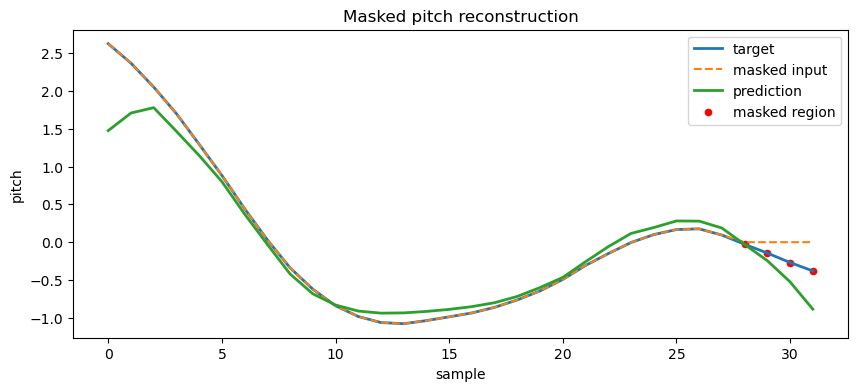

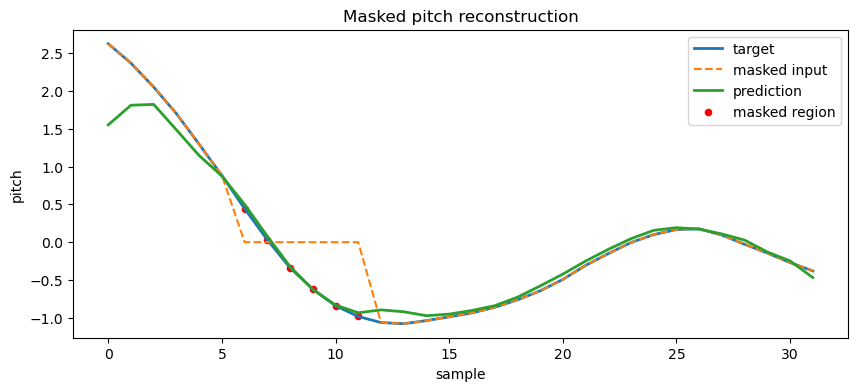

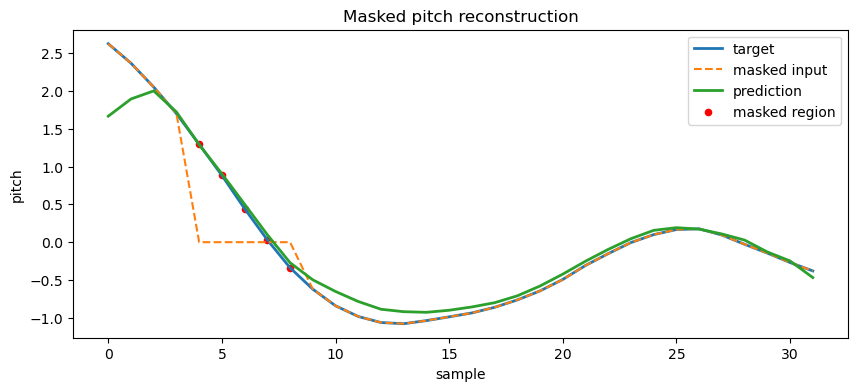

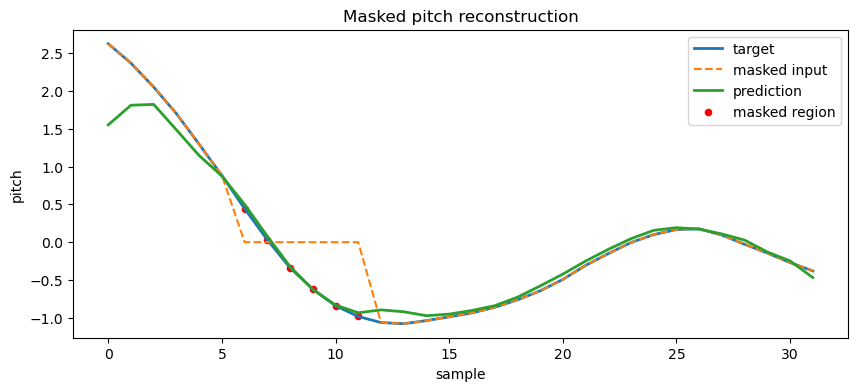

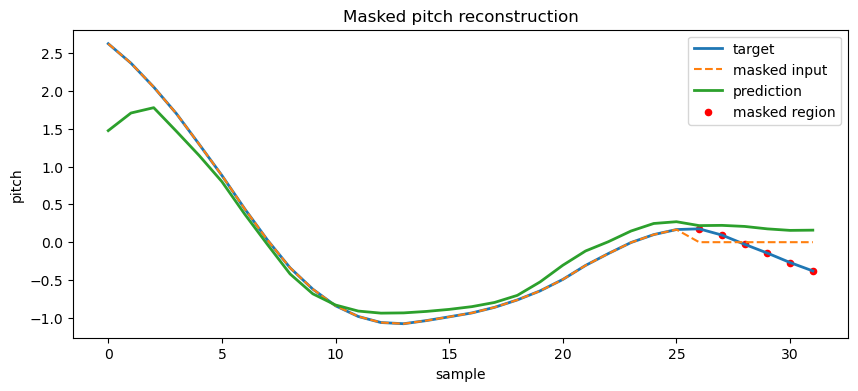

In [95]:
N_EXAMPLES = 5

for i in range(N_EXAMPLES):

    #idx = np.random.randint(len(val_dataset)) #wether
    idx = 300 # or

    x_masked, pred, target, mask = reconstruct_window(
        model,
        val_dataset,
        idx,
        device=DEVICE
    )

    plot_reconstruction(x_masked, pred, target, mask)